<a id='top'></a>
# CONTENTS
- Section 1: General publication trends
  - Question 1: ⁠How many scientific publications on AI have been published since 2010?
- Section 2:
  - Question 1: Which AI subtopics are most represented in publications?
  - Question 2: ⁠How has the popularity of subtopics changed over time?
- Section 3:
  - Question 1: Which countries publish the most articles on AI and how has their ratio changed over the years?
  - Question 2: How are publications distributed by year for each country?
  - Question 3: Which countries are showing the fastest growth in scientific activity in AI?
  - Question 4: Is the global balance of research changing?
- Section 4:
  - Question 1: How is the contribution of authors distributed?
  - Question 2: How has the average number of authors per publication changed over time?
  - Question 3: Has the number of international collaborations increased?
  - Question 4: Has there been an increase in international collaborations?
- Section 5:
  - Question 1: Which universities and research centers publish the most articles on AI?
  - Question 2: How has the contribution of leading institutions changed over time?
  - Question 3: Are institutions specialized in AI subtopics?
  - Question 4: Do academic or industrial research centers dominate?
- Section 6: [Quality and impact of research](#s6)
  - Question 1: [Popular conferences & journals](#s6q1)
  - Question 2: [Citations in categories](#s6q2)
- Section 7: [Evolution of science and trends](#s7)
  - Question 1: [Trends and applications](#s7q1)
- Section 8: [Data limitations](#s8)
  - Question 1: [Poor representations](#s8q1)

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path

import src.plot_questions as pq

warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110

path = Path("query-results")

In [4]:
df_1_1 = pd.read_csv('query-results/QSection1-1.csv')
df_2_1 = pd.read_csv('query-results/QSection2-1.csv')
df_2_2 = pd.read_csv('query-results/QSection2-2.csv')

# PART  1
Shape, dtypes, missing values, and descriptive statistics for **QSection1-1**, **QSection2-1**, and **QSection2-2**.

In [5]:
datasets = {
    'QSection1-1  (AI Publications per Year)': df_1_1,
    'QSection2-1  (Publications by Venue)':    df_2_1,
    'QSection2-2  (Publications by Topic/Year)': df_2_2,
}

for name, df in datasets.items():
    display(df.describe(include="all").round(2))
    display(df.head())
    print()

,year,count
count,52.00,52.00
mean,1999.21,3136.58
std,15.65,4277.08
min,1969.00,64.00
25%,1986.75,460.00
50%,1999.50,1252.00
75%,2012.25,3520.00
max,2025.00,16867.00


,year,count
0,1969,64
1,1971,67
2,1973,86
3,1975,149
4,1977,236


,topic,count
count,13,13.00
unique,13,NaN
top,2. Computer Vision (CVPR),NaN
freq,1,NaN
mean,NaN,15146.31
std,NaN,8815.68
min,NaN,1595.00
25%,NaN,11804.00
50%,NaN,15709.00
75%,NaN,17697.00


,topic,count
0,2. Computer Vision (CVPR),31677
1,4. General AI (AAAI),25882
2,1. Machine Learning (NeurIPS),25179
3,3. NLP & GenAI (ACL),17697
4,1. Machine Learning (ICML),17048


,year,topic,count
count,64.00,64,64.00
unique,NaN,4,NaN
top,NaN,1. Machine Learning,NaN
freq,NaN,16,NaN
mean,2017.50,NaN,1764.70
std,4.65,NaN,1644.02
min,2010.00,NaN,77.00
25%,2013.75,NaN,672.50
50%,2017.50,NaN,998.00
75%,2021.25,NaN,2555.00


,year,topic,count
0,2010,1. Machine Learning,475
1,2010,2. Computer Vision,694
2,2010,3. NLP,393
3,2010,4. Knowledge Rep,95
4,2011,1. Machine Learning,474


---
## QSection1-1 — AI Publications Over Time
Year-by-year publication counts from **1969 – 2025**.

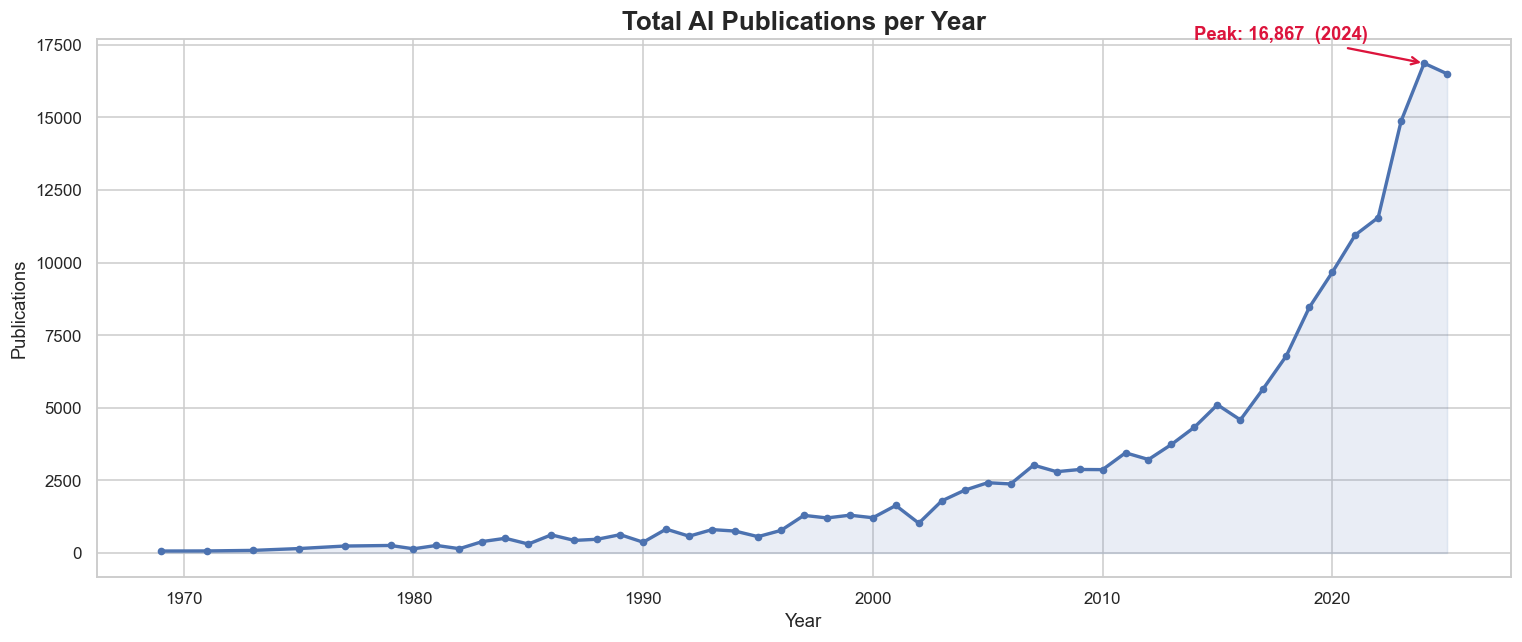

  Total publications : 163,102
  Year range         : 1969 – 2025
  Peak year          : 2024 (16,867 papers)
  Median annual count: 1,252


In [6]:
df1 = df_1_1.sort_values('year').copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df1['year'], df1['count'], marker='o', ms=4, lw=2.2, color='#4C72B0')
ax.fill_between(df1['year'], df1['count'], alpha=0.12, color='#4C72B0')

# annotate peak
peak = df1.loc[df1['count'].idxmax()]
ax.annotate(f"Peak: {peak['count']:,}  ({int(peak['year'])})",
            xy=(peak['year'], peak['count']),
            xytext=(peak['year']-10, peak['count']+800),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
            fontsize=12, color='crimson', fontweight='bold')

ax.set_title('Total AI Publications per Year', fontsize=17, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Publications')
plt.tight_layout(); plt.show()

print(f"  Total publications : {df1['count'].sum():,}")
print(f"  Year range         : {df1['year'].min()} – {df1['year'].max()}")
print(f"  Peak year          : {int(peak['year'])} ({peak['count']:,} papers)")
print(f"  Median annual count: {df1['count'].median():,.0f}")

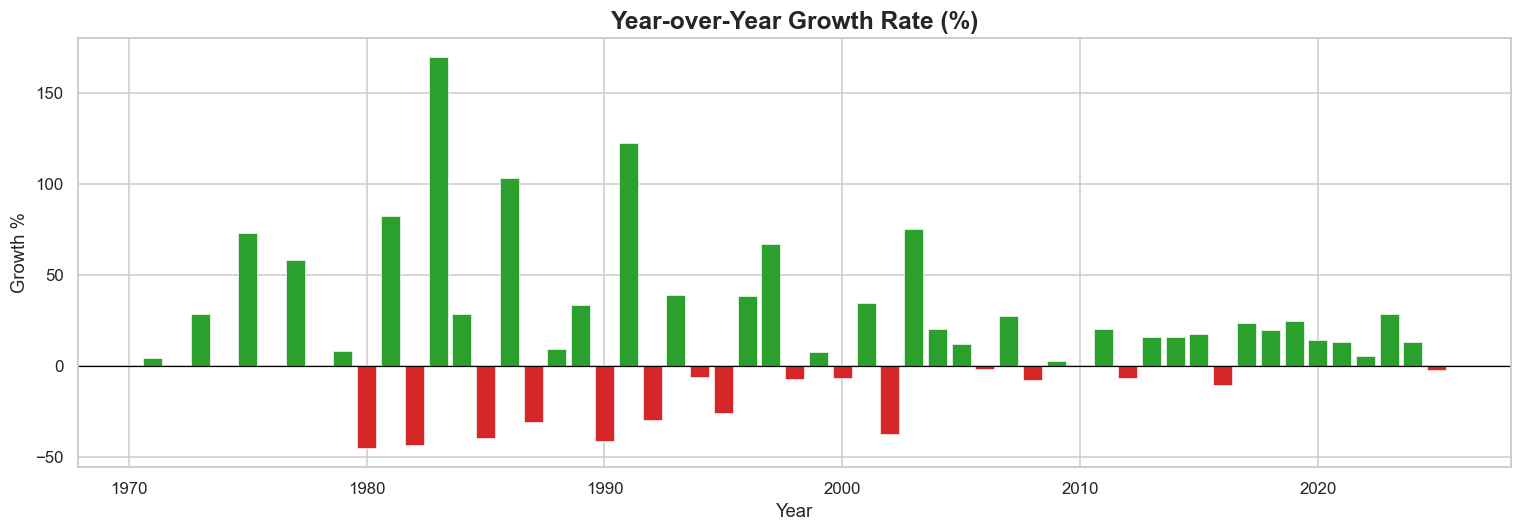

  Years with positive growth : 34
  Years with negative growth : 17
  Mean positive growth       : 37.1%
  Mean negative growth       : -20.1%
  Largest single-year jump   : 1983  (+169.7%)


In [7]:
df1['yoy_pct'] = df1['count'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))
clrs = ['#2ca02c' if v >= 0 else '#d62728' for v in df1['yoy_pct'].fillna(0)]
ax.bar(df1['year'], df1['yoy_pct'], color=clrs, edgecolor='white', lw=0.4)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Year-over-Year Growth Rate (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Growth %')
plt.tight_layout(); plt.show()

pos = df1[df1['yoy_pct'] > 0]['yoy_pct']
neg = df1[df1['yoy_pct'] < 0]['yoy_pct']
print(f"  Years with positive growth : {len(pos)}")
print(f"  Years with negative growth : {len(neg)}")
print(f"  Mean positive growth       : {pos.mean():.1f}%")
print(f"  Mean negative growth       : {neg.mean():.1f}%")
print(f"  Largest single-year jump   : {df1.loc[df1['yoy_pct'].idxmax(), 'year']:.0f}  (+{df1['yoy_pct'].max():.1f}%)")

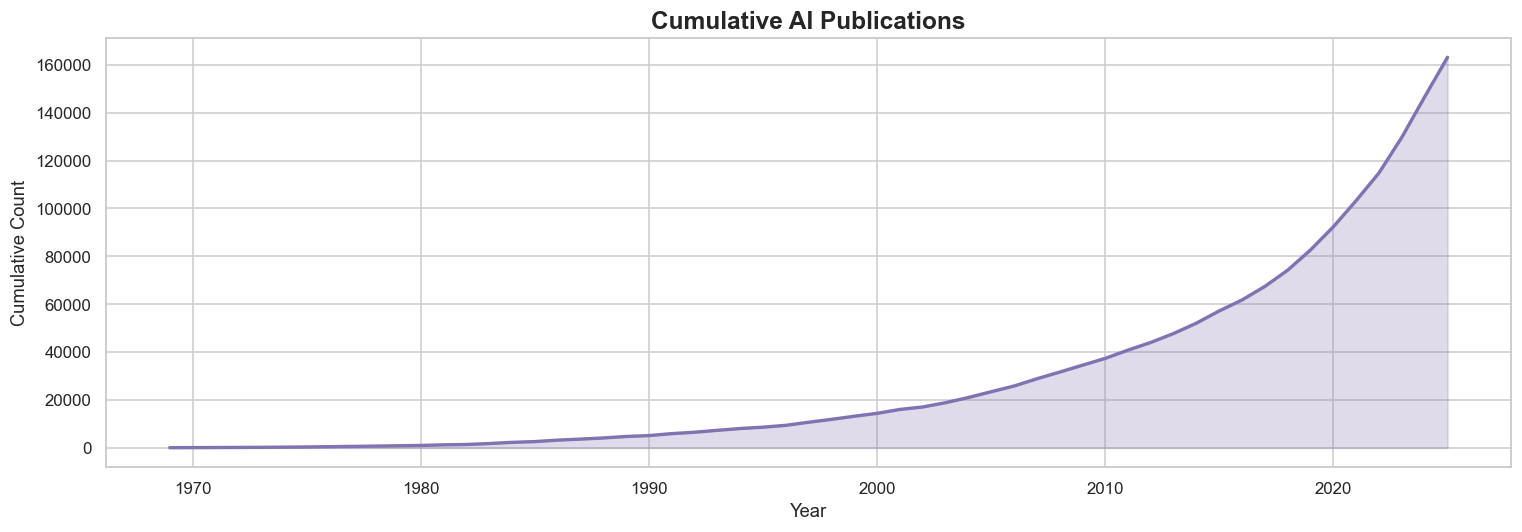

  50 % of all publications were produced after 2019


In [8]:
df1['cumulative'] = df1['count'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df1['year'], df1['cumulative'], alpha=0.25, color='#8172B2')
ax.plot(df1['year'], df1['cumulative'], lw=2.2, color='#8172B2')
ax.set_title('Cumulative AI Publications', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Count')
plt.tight_layout(); plt.show()

# when did we cross 50 % of total output?
half = df1['cumulative'].iloc[-1] / 2
cross = df1.loc[df1['cumulative'] >= half, 'year'].iloc[0]
print(f"  50 % of all publications were produced after {int(cross)}")

---
## QSection2-1 — Publications by Venue
Total publication count for each major AI conference.

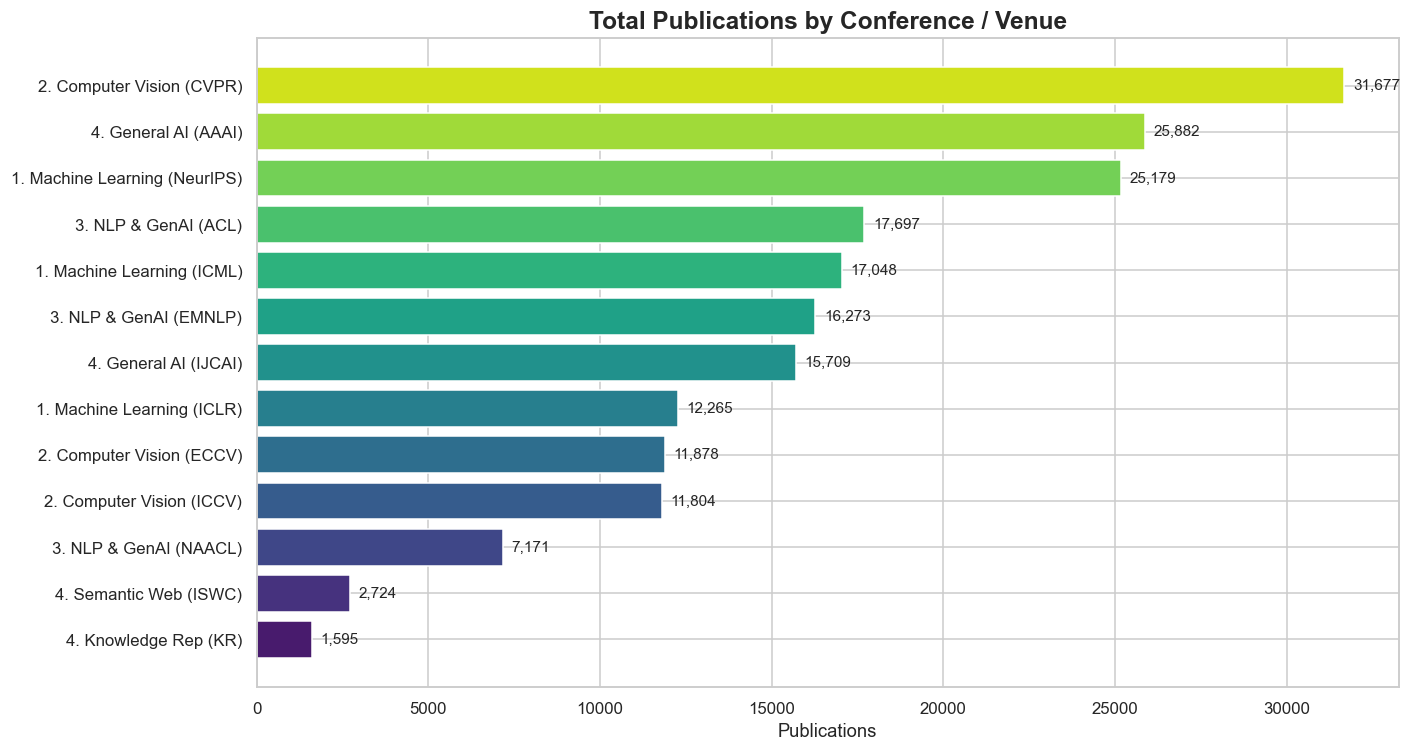

  Total across all venues : 196,902
  Number of venues        : 13
  Top venue               : 2. Computer Vision (CVPR)
  Bottom venue             : 4. Knowledge Rep (KR)
  Mean per venue           : 15,146
  Std dev                  : 8,816


In [9]:
df2 = df_2_1.sort_values('count', ascending=True).copy()

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('viridis', len(df2))
bars = ax.barh(df2['topic'], df2['count'], color=palette, edgecolor='white')
for b in bars:
    w = b.get_width()
    ax.text(w + 250, b.get_y() + b.get_height()/2, f'{w:,.0f}', va='center', fontsize=10)
ax.set_title('Total Publications by Conference / Venue', fontsize=16, fontweight='bold')
ax.set_xlabel('Publications')
plt.tight_layout(); plt.show()

print(f"  Total across all venues : {df_2_1['count'].sum():,}")
print(f"  Number of venues        : {len(df_2_1)}")
print(f"  Top venue               : {df_2_1.loc[df_2_1['count'].idxmax(), 'topic']}")
print(f"  Bottom venue             : {df_2_1.loc[df_2_1['count'].idxmin(), 'topic']}")
print(f"  Mean per venue           : {df_2_1['count'].mean():,.0f}")
print(f"  Std dev                  : {df_2_1['count'].std():,.0f}")

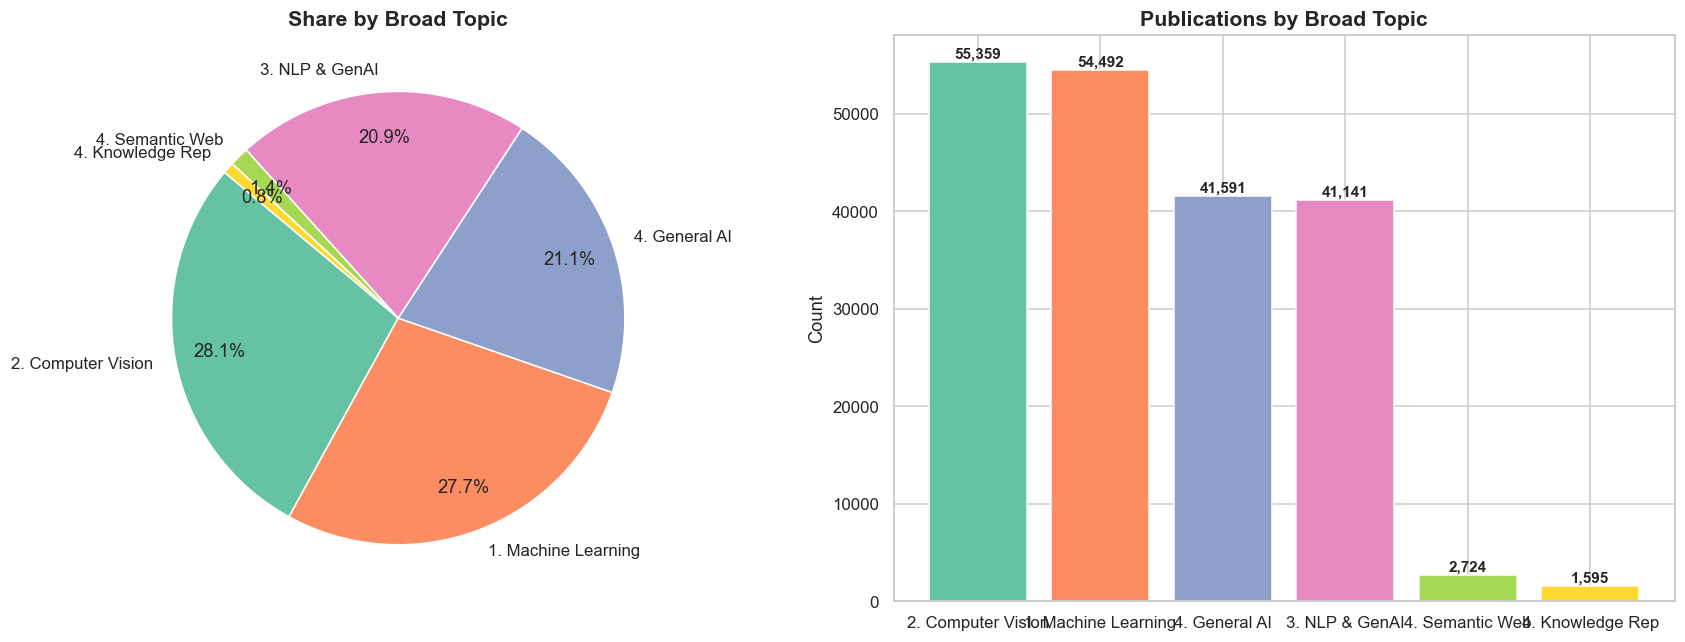

  Broad-topic breakdown:
    2. Computer Vision        →  55,359  (28.1%)
    1. Machine Learning       →  54,492  (27.7%)
    4. General AI             →  41,591  (21.1%)
    3. NLP & GenAI            →  41,141  (20.9%)
    4. Semantic Web           →   2,724  (1.4%)
    4. Knowledge Rep          →   1,595  (0.8%)


In [10]:
# extract broad topic from the prefix  e.g. "1. Machine Learning"
df_2_1['broad'] = df_2_1['topic'].str.extract(r'^(\d+\..+?)\s*\(')[0]
topic_agg = df_2_1.groupby('broad')['count'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('Set2', len(topic_agg))

# pie
axes[0].pie(topic_agg, labels=topic_agg.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.80)
axes[0].set_title('Share by Broad Topic', fontsize=14, fontweight='bold')

# bar
axes[1].bar(topic_agg.index, topic_agg.values, color=colors, edgecolor='white')
for i, v in enumerate(topic_agg.values):
    axes[1].text(i, v + 400, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Publications by Broad Topic', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

print('  Broad-topic breakdown:')
for t, c in topic_agg.items():
    print(f'    {t:25s} → {c:>7,}  ({c/topic_agg.sum()*100:.1f}%)')

---
## QSection2-2 — Topic Trends Over Time
Yearly publication counts for each AI research topic (2010–2025).

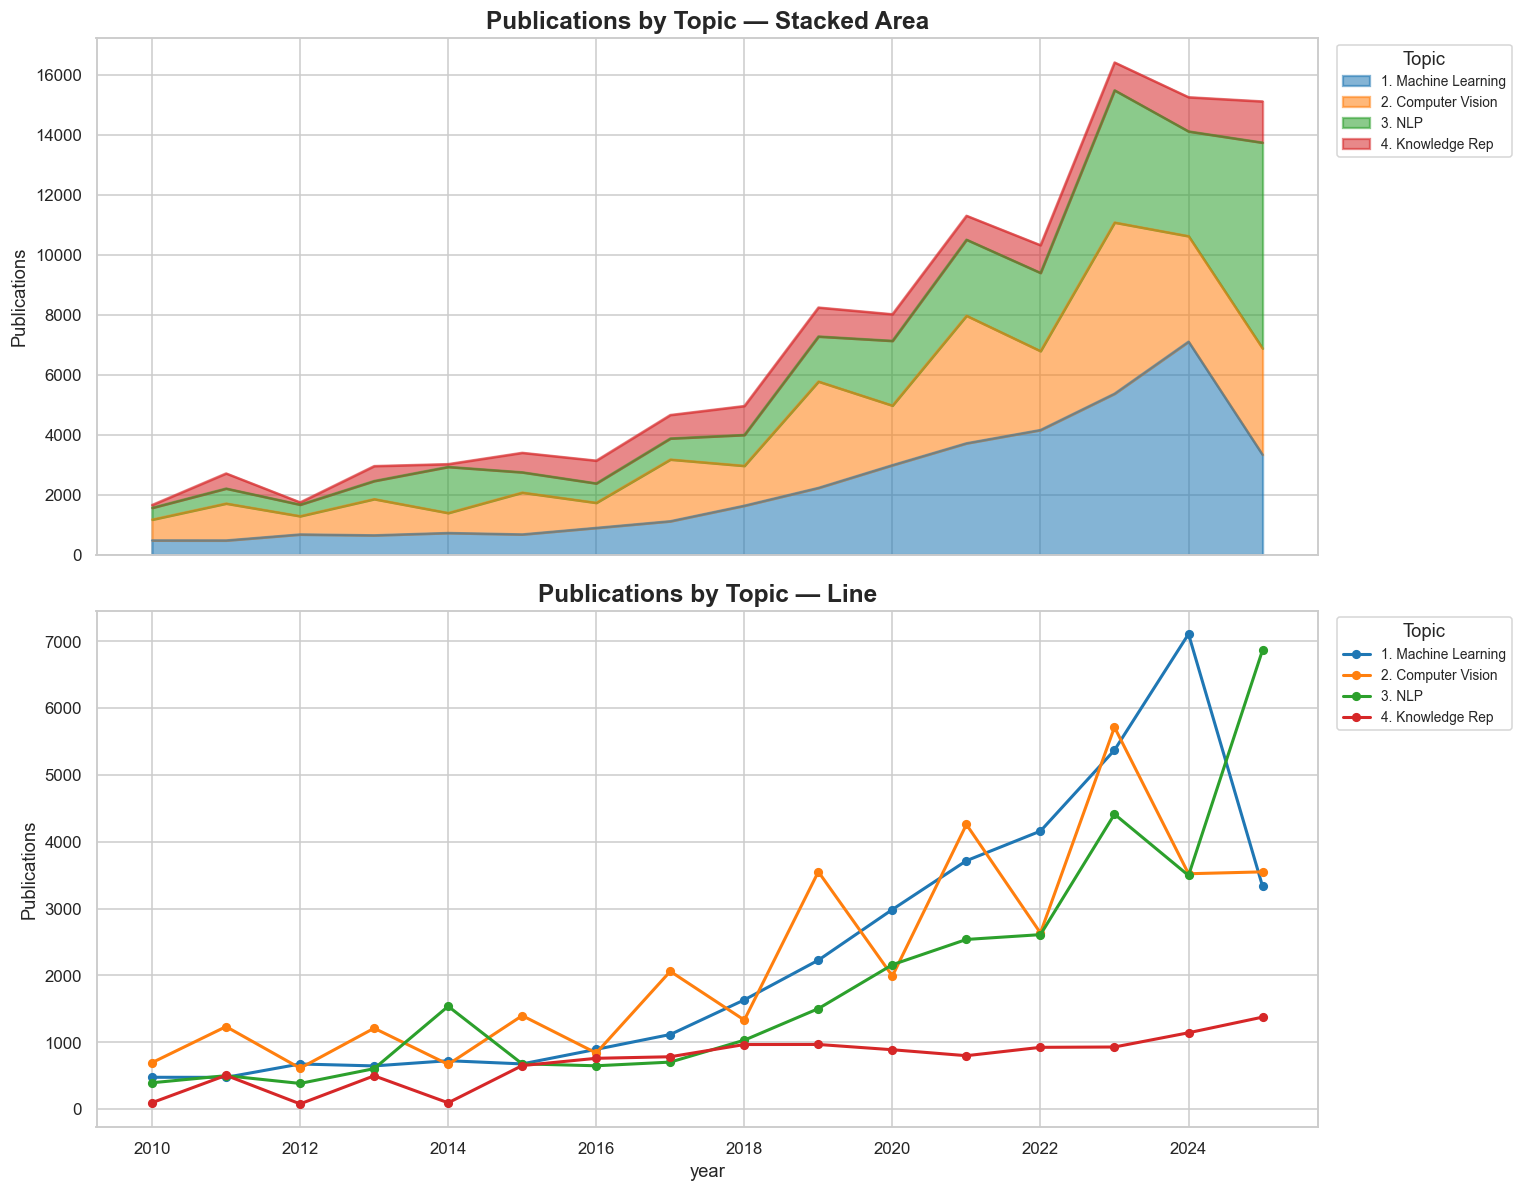

  Latest year totals (2025):
    1. Machine Learning    →  3,332
    2. Computer Vision     →  3,548
    3. NLP                 →  6,866
    4. Knowledge Rep       →  1,375


In [11]:
pivot = df_2_2.pivot_table(index='year', columns='topic', values='count', aggfunc='sum')
cpal = sns.color_palette('tab10', len(pivot.columns))

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

pivot.plot.area(ax=axes[0], alpha=0.55, color=cpal, lw=1.5)
axes[0].set_title('Publications by Topic — Stacked Area', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Publications')
axes[0].legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

pivot.plot(ax=axes[1], marker='o', ms=5, lw=2, color=cpal)
axes[1].set_title('Publications by Topic — Line', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Publications')
axes[1].legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()

print('  Latest year totals (2025):')
for col in pivot.columns:
    print(f'    {col:22s} → {pivot[col].iloc[-1]:>6,.0f}')

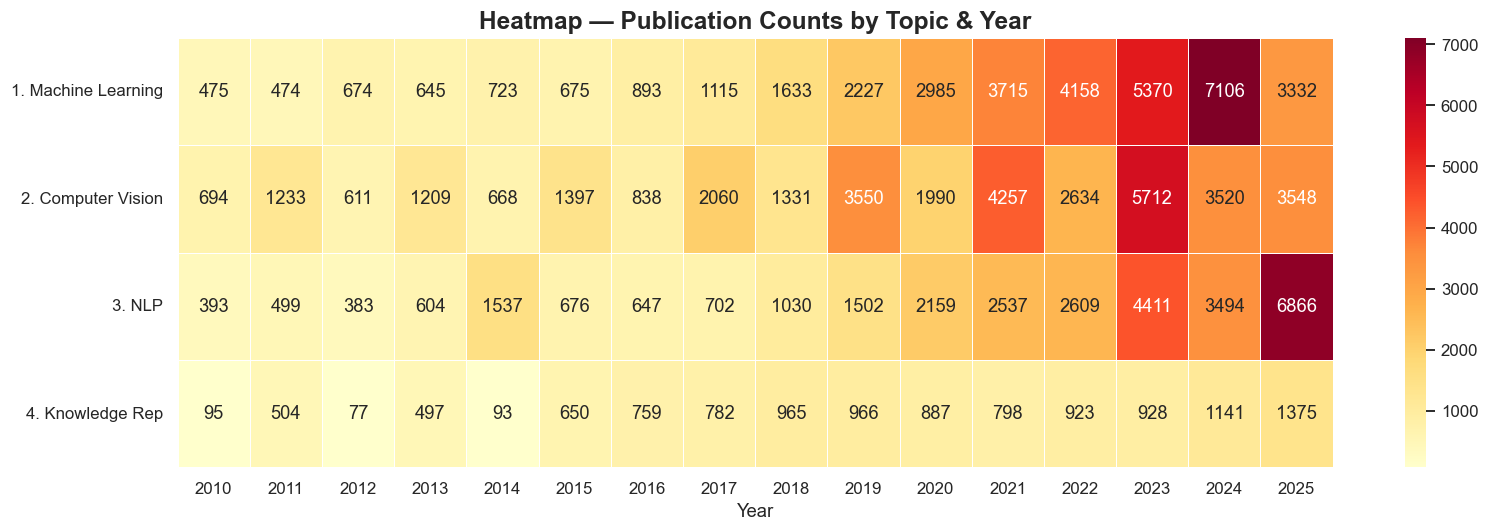

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot.T, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=.5, ax=ax)
ax.set_title('Heatmap — Publication Counts by Topic & Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

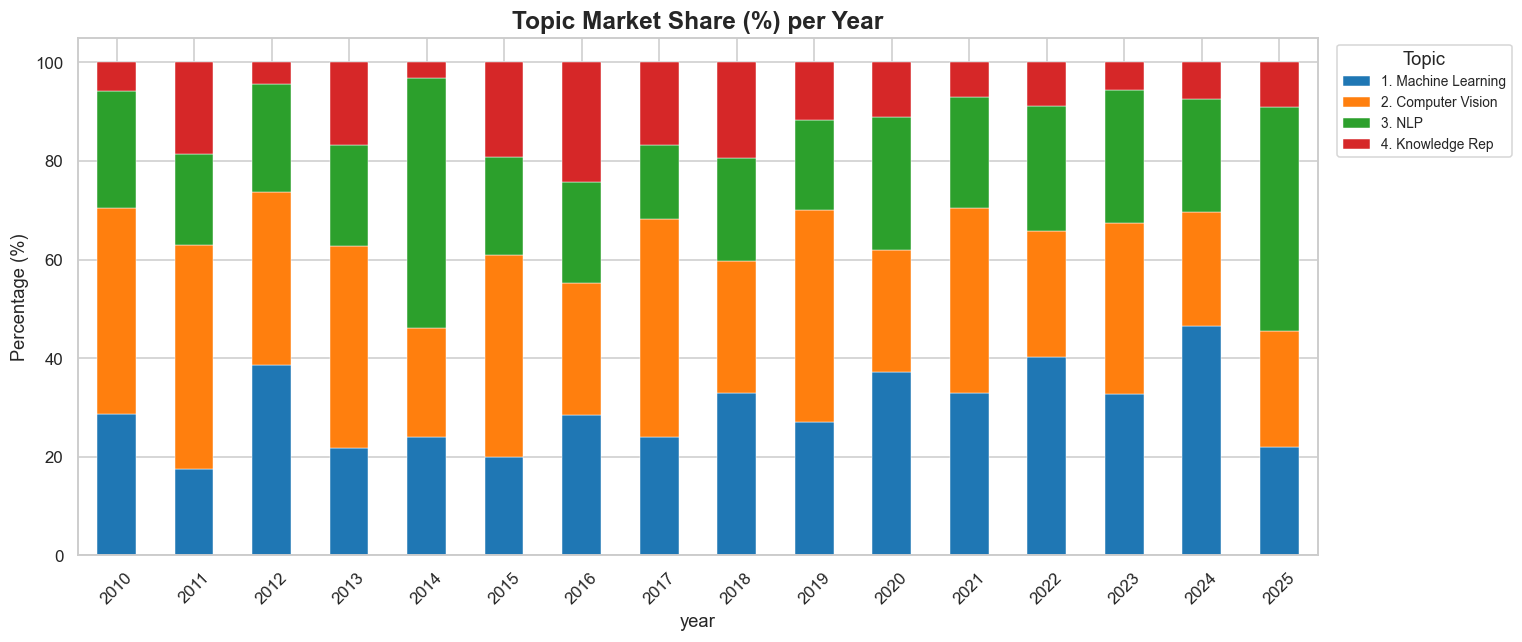

  Dominant topic per year:
    2010  →  2. Computer Vision (41.9%)
    2011  →  2. Computer Vision (45.5%)
    2012  →  1. Machine Learning (38.6%)
    2013  →  2. Computer Vision (40.9%)
    2014  →  3. NLP (50.9%)
    2015  →  2. Computer Vision (41.1%)
    2016  →  1. Machine Learning (28.5%)
    2017  →  2. Computer Vision (44.2%)
    2018  →  1. Machine Learning (32.9%)
    2019  →  2. Computer Vision (43.1%)
    2020  →  1. Machine Learning (37.2%)
    2021  →  2. Computer Vision (37.6%)
    2022  →  1. Machine Learning (40.3%)
    2023  →  2. Computer Vision (34.8%)
    2024  →  1. Machine Learning (46.6%)
    2025  →  3. NLP (45.4%)


In [13]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot.bar(stacked=True, ax=ax, color=cpal, edgecolor='white', lw=.3)
ax.set_title('Topic Market Share (%) per Year', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()], rotation=45)
plt.tight_layout(); plt.show()

print('  Dominant topic per year:')
for yr in pivot_pct.index:
    dom = pivot_pct.loc[yr].idxmax()
    print(f'    {yr}  →  {dom} ({pivot_pct.loc[yr, dom]:.1f}%)')

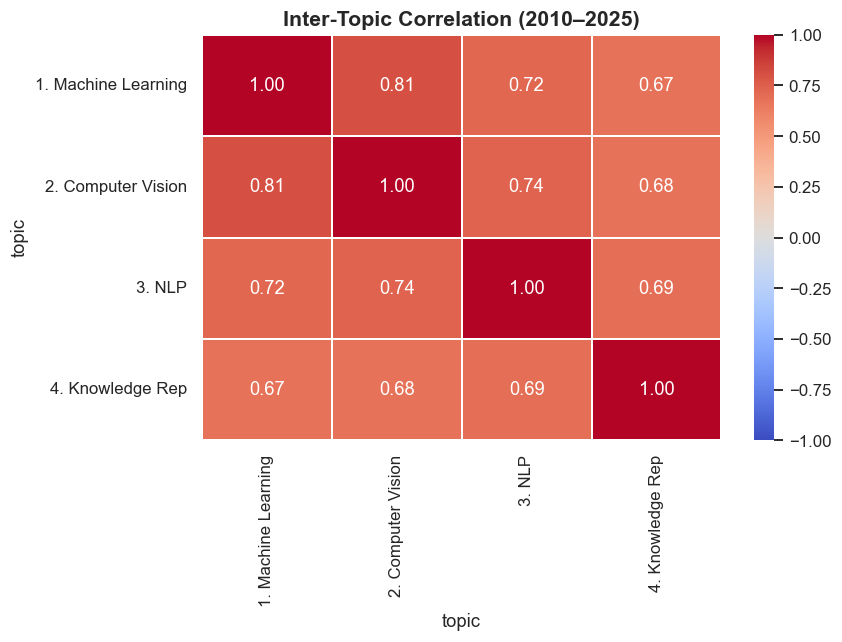


Compound Annual Growth Rate (CAGR) 2010 → 2025
────────────────────────────────────────────────────
    1. Machine Learning      +13.9%
    2. Computer Vision       +11.5%
    3. NLP                   +21.0%
    4. Knowledge Rep         +19.5%

  ⮞ Fastest-growing topic : 3. NLP  (+21.0% CAGR)
  ⮞ Slowest-growing topic : 2. Computer Vision  (+11.5% CAGR)

═══════════════════════════════════════════════════════
  OVERALL SUMMARY
═══════════════════════════════════════════════════════
  Total AI publications (1969–2025)    :    163,102
  Total across 13 venues (QSection2-1) :    196,902
  Publications in 2025 alone           :     16,504
  Number of venues analysed            :         13
  Number of broad topics               :          6
  Year span in QSection2-2             : 2010 – 2025
  Top venue by output                  : 2. Computer Vision (CVPR)
  Dominant broad topic                 : 2. Computer Vision  (55,359)


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=1, ax=ax)
ax.set_title('Inter-Topic Correlation (2010–2025)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── CAGR ──
n = pivot.index[-1] - pivot.index[0]  # years
print('\nCompound Annual Growth Rate (CAGR) 2010 → 2025')
print('─' * 52)
cagrs = {}
for col in pivot.columns:
    v0, v1 = pivot[col].iloc[0], pivot[col].iloc[-1]
    if v0 > 0:
        c = (v1 / v0) ** (1 / n) - 1
        cagrs[col] = c
        print(f'    {col:22s}  {c:>+7.1%}')

fastest = max(cagrs, key=cagrs.get)
slowest = min(cagrs, key=cagrs.get)
print(f'\n  ⮞ Fastest-growing topic : {fastest}  ({cagrs[fastest]:+.1%} CAGR)')
print(f'  ⮞ Slowest-growing topic : {slowest}  ({cagrs[slowest]:+.1%} CAGR)')

# ── Overall summary ──
print('\n' + '═'*55)
print('  OVERALL SUMMARY')
print('═'*55)
print(f'  Total AI publications (1969–2025)    : {df_1_1["count"].sum():>10,}')
print(f'  Total across 13 venues (QSection2-1) : {df_2_1["count"].sum():>10,}')
print(f'  Publications in 2025 alone           : {df_1_1[df_1_1["year"]==2025]["count"].values[0]:>10,}')
print(f'  Number of venues analysed            : {len(df_2_1):>10}')
print(f'  Number of broad topics               : {len(topic_agg):>10}')
print(f'  Year span in QSection2-2             : {pivot.index.min()} – {pivot.index.max()}')
print(f'  Top venue by output                  : {df_2_1.loc[df_2_1["count"].idxmax(), "topic"]}')
print(f'  Dominant broad topic                 : {topic_agg.idxmax()}  ({topic_agg.max():,})')

## Section 3: Geography of research

Question 1: Which countries publish the most AI articles?

In [15]:
df_geography = pd.read_csv(path / 'QSection3-1.csv')
pq.s3q1(df_geography)

        TOP 10 AI COUNTRIES
country
USA            36232
China          25219
UK              6413
Germany         5318
Canada          3586
Singapore       3250
Australia       2940
Switzerland     1966
France          1769
Italy           1400
Name: count, dtype: int64


Question 2: How are publications distributed by year for each country?

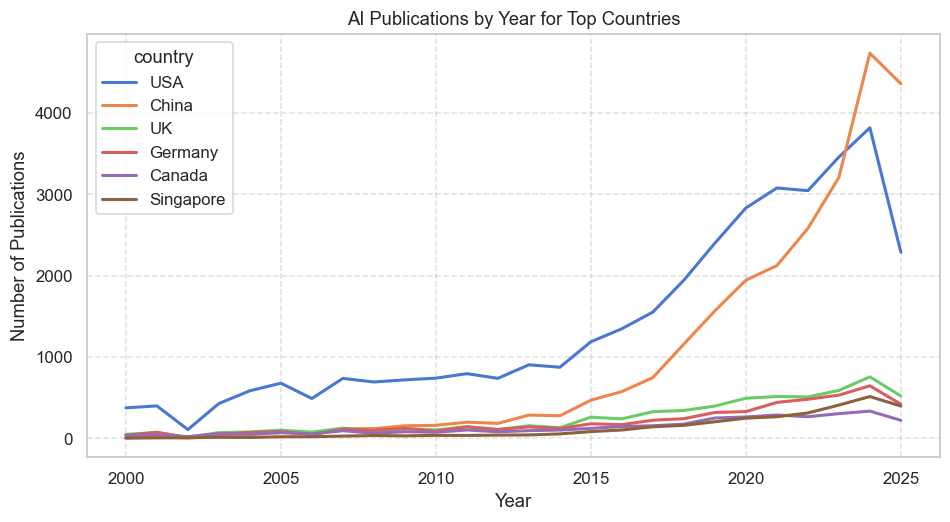

In [16]:
pq.s3q2(df_geography)

Question 3: Which countries are showing the fastest growth in scientific activity in AI?

In [17]:
pq.s3q3(df_geography)

   FASTEST GROWTH (CAGR 2018-2023)
country
South Korea    40.96%
China          22.55%
Singapore      20.56%
Netherlands    19.34%
Germany        16.97%
dtype: str


Question 4: Is the global balance of research changing

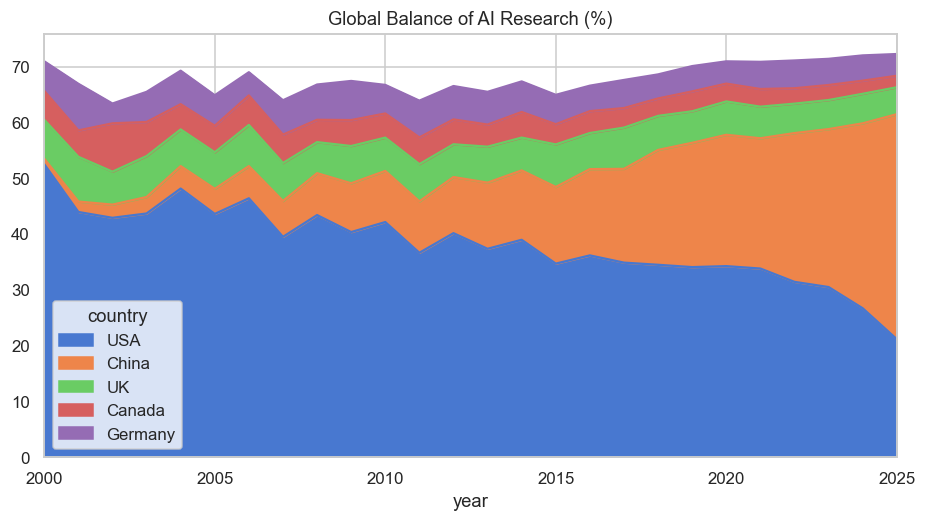

In [18]:
pq.s3q4(df_geography)

## Section 4: Authors and the scientific community 

Question 1: How many unique authors are published in the field of AI?

In [19]:
df_authors = pd.read_csv(path/'QSection4-1.csv')
pq.s4q1(df_authors)

Total Unique Authors in AI: 138,398


Question 2: How is the contribution of authors distributed: are there many “super-productive” researchers?

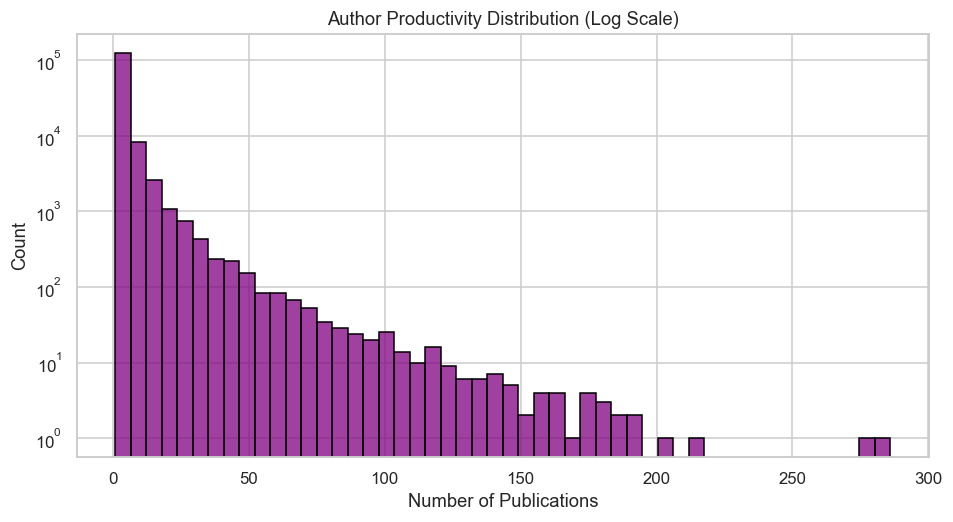

Top 5 Super-Productive Researchers:
 authorName
Dacheng Tao           286
Luc Van Gool          279
Michael I. Jordan     212
Bernhard Schölkopf    206
Radu Timofte          194
Name: pub, dtype: int64


In [20]:
pq.s4q2(df_authors)

Question 3: How has the average number of authors per publication changed over time?

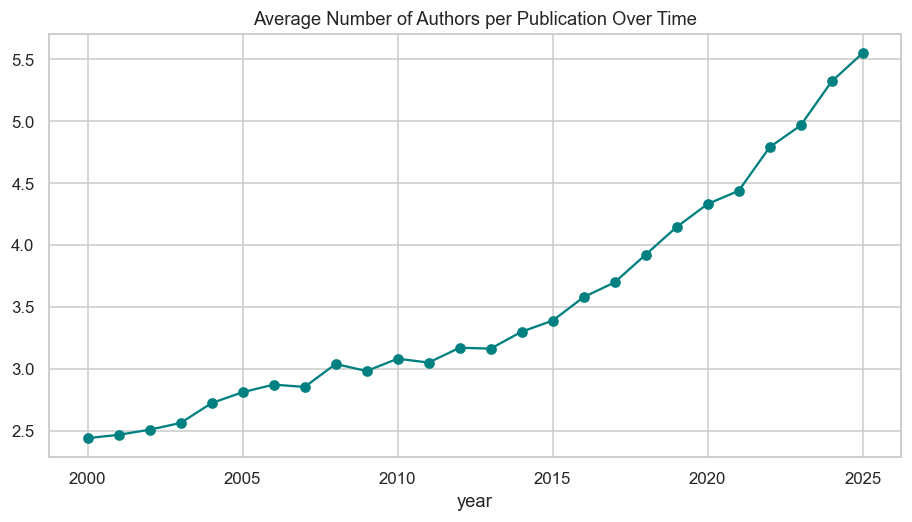

In [21]:
pq.s4q3(df_authors)

Question 4: Has there been an increase in international collaborations?

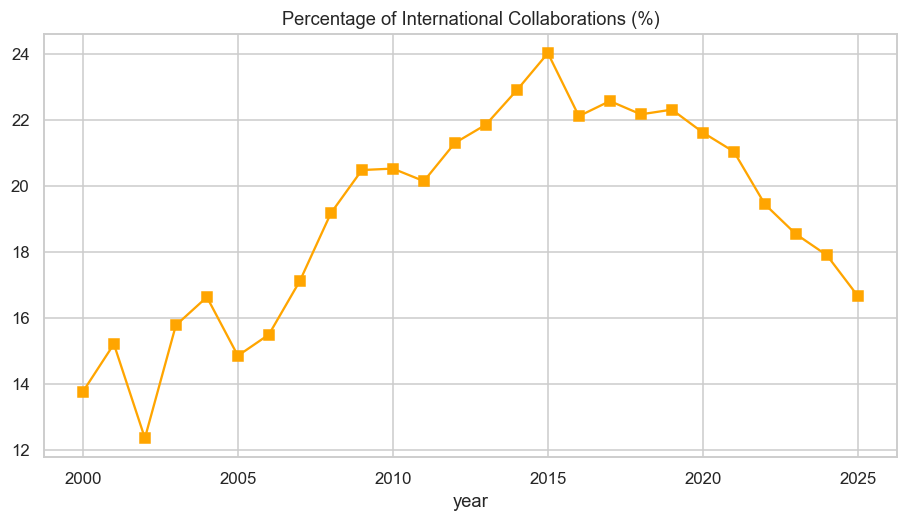

In [22]:
pq.s4q4(df_geography)

 International Collaborations (Percentage vs. Absolute)


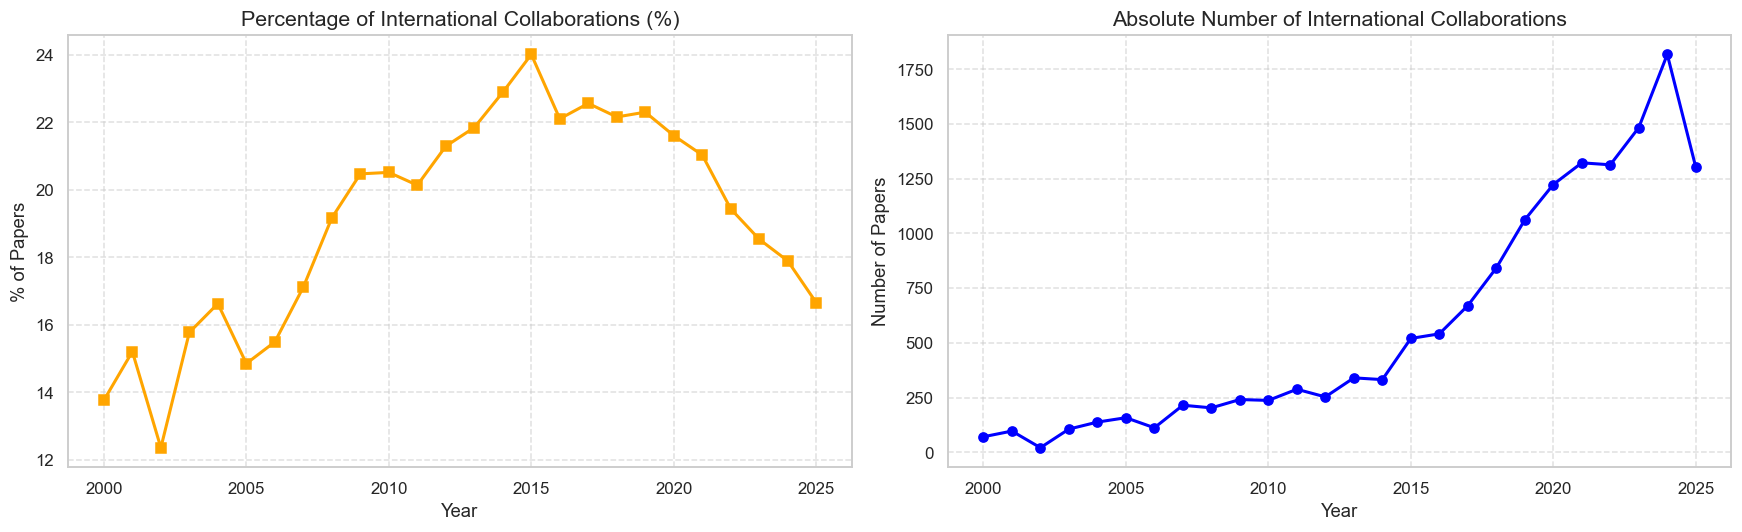

In [23]:
pq.s4q5(df_geography)

## Section 5: Institutions and universities

Question 1: Which universities and research centers publish the most AI articles?

In [24]:
df_institutions = pd.read_csv(path/'QSection5-1.csv')
pq.s5q1(df_institutions)

       TOP 10 INSTITUTIONS
affiliationName
Carnegie Mellon University, Pittsburgh, USA    950
Nanyang Technological University, Singapore    941
University of Oxford, UK                       806
University of California, Berkeley, USA        771
ETH Zurich, Switzerland                        749
Stanford University, USA                       721
Microsoft Research Asia, Beijing, China        692
Stanford University, CA, USA                   646
Tsinghua University, Beijing, China            624
Peking University, Beijing, China              591
Name: count, dtype: int64


Question 2: How has the contribution of leading institutions changed over time?

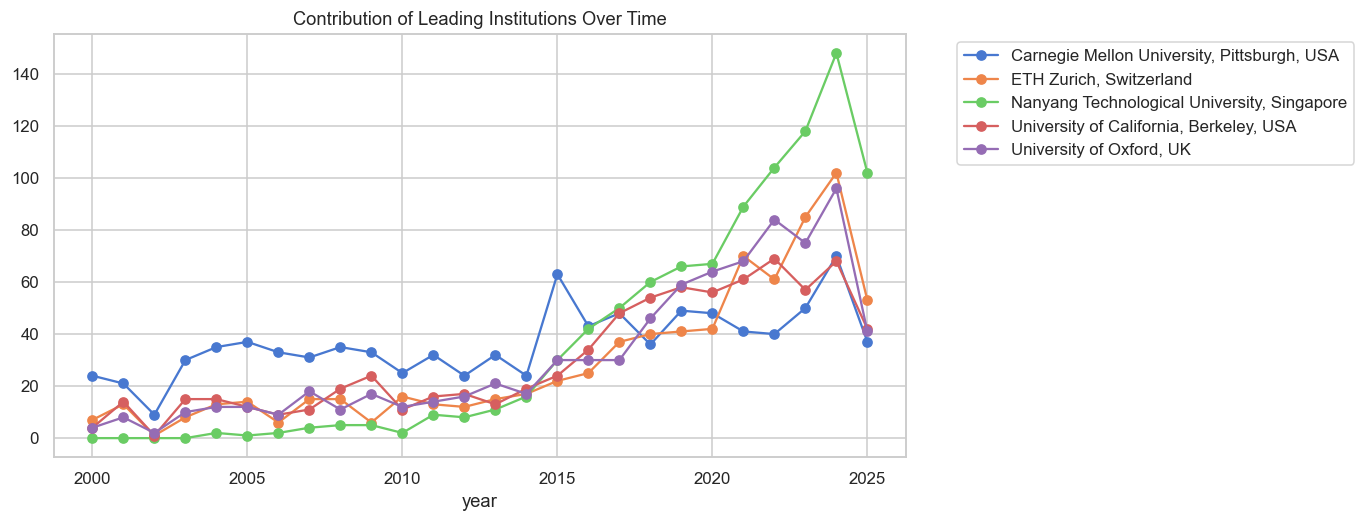

In [25]:
pq.s5q2(df_institutions)

Question 3: Are institutions specialized in AI subtopics?

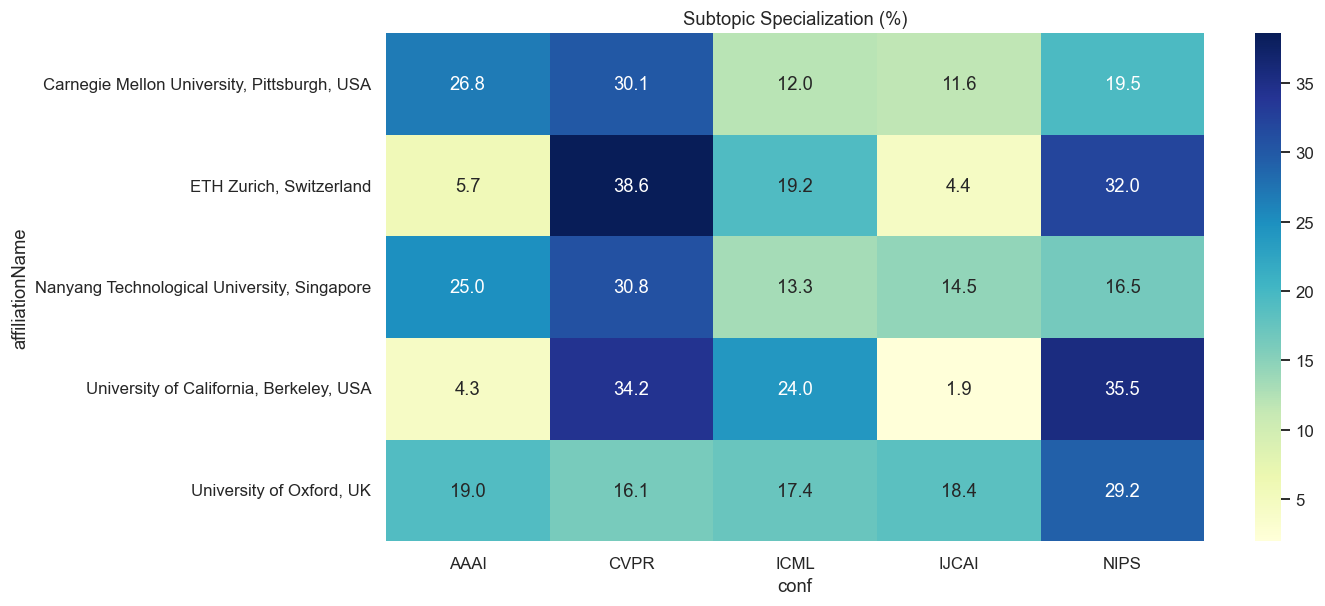

In [26]:
pq.s5q3(df_institutions)

Question 4: Do academic or industrial research centers dominate?

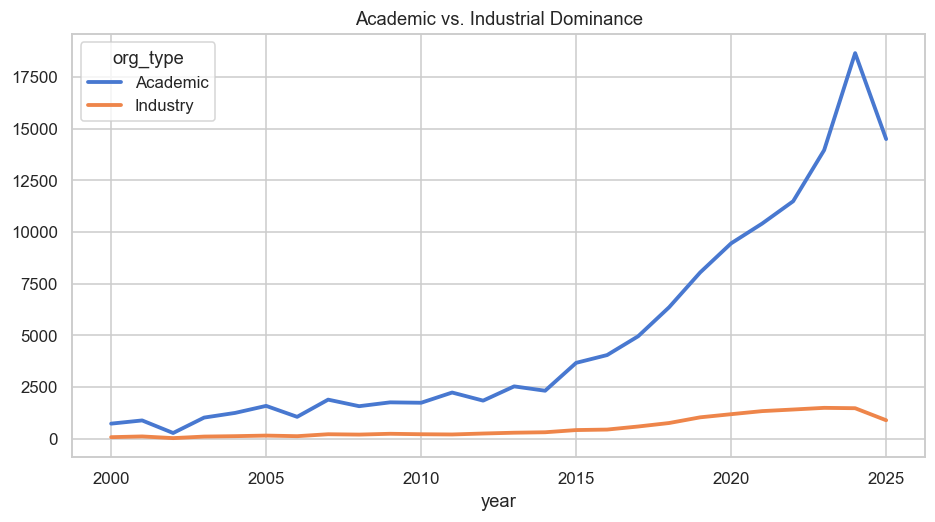

In [27]:
pq.s5q4(df_institutions)

### Section 6: Quality and impact of research
<a id='s6'></a>

Question 1: Which journals and conferences publish the most AI papers?
<a id='s6q1'></a>

In [28]:
popular_articles = pd.read_csv(path / "QSection6-1-1.csv")
popular_conferences = pd.read_csv(path / "QSection6-1-2.csv")

pq.s6q1(popular_articles, popular_conferences)

+-------------------------------+
|        POPULAR ARTICLES       |
+----------------------+--------+
|        venue         | papers |
+----------------------+--------+
|     IEEE Access      | 10616  |
|       Sensors        |  4605  |
|    Neurocomputing    |  4420  |
| Neural Comput. Appl. |  3336  |
|  Expert Syst. Appl.  |  3191  |
+----------------------+--------+
+------------------------------+
|      ARTICLES ANALYSIS       |
+---------+--------------------+
| metrics |       papers       |
+---------+--------------------+
|  count  |       1731.0       |
|   mean  | 91.16522241478914  |
|   std   | 365.83541163796264 |
|   min   |        1.0         |
|   25%   |        5.0         |
|   50%   |        19.0        |
|   75%   |        70.0        |
|   max   |      10616.0       |
+---------+--------------------+
+---------------------+
| POPULAR CONFERENCES |
+----------+----------+
|  venue   |  papers  |
+----------+----------+
|  IJCNN   |   4096   |
|  ICASSP  |   1735 

Question 2: Which AI categories are cited most often?
<a id='s6q2'></a>

In [29]:
ai_citations = pd.read_csv(path / "QSection6-2-1.csv")

pq.s6q2(ai_citations)

+------------------------------------------------------------+
|                   OVERVIEW OF CATEGORIES                   |
+------------------------------+------------+----------------+
|           category           | paperCount | totalCitations |
+------------------------------+------------+----------------+
|       Computer Vision        |   17547    |     410567     |
|   Image & Media Synthesis    |   13137    |     293935     |
|     Generative AI & LLMs     |    7737    |     154090     |
|    Reinforcement Learning    |    6713    |     110616     |
|   Privacy & Distributed AI   |    4453    |     92807      |
| AI Ethics & Interpretability |    5229    |     84042      |
|        Classical NLP         |    3777    |     82478      |
|        Graph Learning        |    1493    |     25446      |
|      AI Hardware & Edge      |    771     |     12697      |
+------------------------------+------------+----------------+
+--------------------------------------------------+
| 

+------------------------------+
| CITATIONS PER PAPER ANALYSIS |
+---------+--------------------+
| metrics |    citPerPaper     |
+---------+--------------------+
|  count  |        9.0         |
|   mean  | 19.38099999791879  |
|   std   | 2.8912202168066616 |
|   min   | 16.072289156626507 |
|   25%   | 16.47787874273797  |
|   50%   | 19.91598810908621  |
|   75%   | 21.836907598623245 |
|   max   | 23.398130734598507 |
+---------+--------------------+


### Section 7: Evolution of science and trends
<a id='s7'></a>

Question 1: How quickly do new subtopics enter the mainstream, and is there a time lag between fundamental and applied areas?
<a id='s7q1'></a>

In [30]:
df_from2021onwards = pd.read_csv(path / 'QSection7-1-1-1.csv')
df_before2011 = pd.read_csv(path / 'QSection7-1-1-2.csv')
df_2011to2021 = pd.read_csv(path / 'QSection7-1-1-3.csv')
funap_df = pd.read_csv(path / 'QSection7-1-2.csv')

pq.s7q1(df_before2011, df_from2021onwards, df_2011to2021, funap_df)

+--------------------------------------------------------------------------+
|                           EVOLUTION OF TOPICS                            |
+---------------------------+-----------+--------------------+-------------+
|          subtopic         | birthYear |      avgYear       | totalVolume |
+---------------------------+-----------+--------------------+-------------+
|       AI for Science      |    1992   | 2015.1654228854243 |     804     |
|          Deep RL          |    1988   | 2021.2730342933382 |    55667    |
| Ethics & Interpretability |    1993   | 2023.3840822177062 |     4184    |
|      Generative Media     |    1972   | 2022.4746157003742 |    21923    |
|       Graph Learning      |    1993   | 2022.9226091501046 |    21049    |
|      LLMs & Attention     |    1948   | 2023.5082969430823 |    116790   |
|  Neural Rendering (NeRF)  |    1974   | 2019.428111932916  |     6218    |
|   Privacy-Preserving AI   |    2005   | 2023.023336030567  |    23483    |

+-----------------------------+
|       VOLUME PER YEAR       |
+---------+-------------------+
| metrics |     volPerYear    |
+---------+-------------------+
|  count  |        8.0        |
|   mean  |      673.625      |
|   std   | 609.9676660048699 |
|   min   |        23.0       |
|   25%   |       124.25      |
|   50%   |       521.0       |
|   75%   |       1204.5      |
|   max   |       1497.0      |
+---------+-------------------+


+---------------------------------------+
|            FIELDS OVERVIEW            |
+-------------+----------------+--------+
|     type    |    avgYear     | count  |
+-------------+----------------+--------+
|   Applied   | 2012.986247586 | 661193 |
| Fundamental | 2011.895347902 | 74590  |
+-------------+----------------+--------+


### Section 8: Data limitations
<a id='s7'></a>

Question 1: Which entities are worst represented?
<a id='s8q1'></a>

In [31]:
affiliation_df = pd.read_csv(path / 'QSection8-1-1.csv')
citations_df = pd.read_csv(path / 'QSection8-1-2.csv')

pq.s8q1(affiliation_df, citations_df)

+----------------------------------------------+
|        MISSING AFFILIATION OF PAPERS         |
+---------------+---------------------+--------+
|    subtopic   |    hasAffiliation   | count  |
+---------------+---------------------+--------+
| Generative AI | Missing Affiliation | 110385 |
|       RL      | Missing Affiliation | 55288  |
|     Vision    | Missing Affiliation |  7331  |
+---------------+---------------------+--------+
+-----------------------------+
|     AFFILIATION ANALYSIS    |
+---------+-------------------+
| metrics |       count       |
+---------+-------------------+
|  count  |        3.0        |
|   mean  |      57668.0      |
|   std   | 51568.20754108097 |
|   min   |       7331.0      |
|   25%   |      31309.5      |
|   50%   |      55288.0      |
|   75%   |      82836.5      |
|   max   |      110385.0     |
+---------+-------------------+


+--------------------------------------------+
|    OVERVIEW OF CITATIONS IN CATEGORIES     |
+---------------+-------------------+--------+
|    subtopic   |   citationStatus  | count  |
+---------------+-------------------+--------+
| Generative AI | Citations Tracked |  7433  |
| Generative AI |  No Citation Data | 102954 |
|       RL      | Citations Tracked |  7852  |
|       RL      |  No Citation Data | 47439  |
|     Vision    | Citations Tracked |  1112  |
|     Vision    |  No Citation Data |  6221  |
+---------------+-------------------+--------+


[Back to top](#top)